In [1]:
# -----------------------------------------------
# CUSTOMER CHURN PREDICTION
# Author: Priya Upadhyay
# Date: June 2026
# Description: Random Forest model to predict
#              telecom customer churn
# -----------------------------------------------

# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# -----------------------------------------------
# STEP 1: LOAD DATA
# -----------------------------------------------

# Load the customer data CSV
df = pd.read_csv(r'C:\Users\iampr\OneDrive\Desktop\Customer_Data.csv')

# Check it loaded correctly
print("Shape:", df.shape)
print("\nCustomer Status breakdown:")
print(df['Customer_Status'].value_counts())

print("\nFirst 5 rows:")
df.head()

Shape: (6418, 32)

Customer Status breakdown:
Customer_Status
Stayed     4275
Churned    1732
Joined      411
Name: count, dtype: int64

First 5 rows:


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [4]:
# -----------------------------------------------
# STEP 2: DATA PREPROCESSING
# -----------------------------------------------

# Separate data into training data and new joiner data
churn_data = df[df['Customer_Status'].isin(['Churned', 'Stayed'])]
joiner_data = df[df['Customer_Status'] == 'Joined']

print("Churn data shape:", churn_data.shape)
print("Joiner data shape:", joiner_data.shape)

# Drop columns not needed for prediction
churn_data = churn_data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)

print("\nColumns remaining:", churn_data.shape[1])
print("\n✅ Data split complete!")

Churn data shape: (6007, 32)
Joiner data shape: (411, 32)

Columns remaining: 29

✅ Data split complete!


In [5]:
# -----------------------------------------------
# STEP 3: LABEL ENCODING
# -----------------------------------------------

# List of all text columns to encode
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 
    'Multiple_Lines', 'Internet_Service', 'Internet_Type', 
    'Online_Security', 'Online_Backup', 'Device_Protection_Plan', 
    'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 
    'Paperless_Billing', 'Payment_Method'
]

# Apply label encoding to each column
label_encoders = {}
for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    churn_data[column] = label_encoders[column].fit_transform(churn_data[column])

# Encode target variable
churn_data['Customer_Status'] = churn_data['Customer_Status'].map(
    {'Stayed': 0, 'Churned': 1}
)

print("Encoding complete!")
print("\nSample of encoded data:")
churn_data.head()

Encoding complete!

Sample of encoded data:


,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status
0,1,35,0,4,7,27,5,1,0,1,...,1,1,1,65.6,593.30,0.00,0,381.51,974.81,0
1,0,45,1,12,14,13,5,1,1,1,...,0,0,1,-4.0,542.40,38.33,10,96.21,610.28,0
2,1,51,0,21,4,35,4,1,0,1,...,0,1,0,73.9,280.85,0.00,0,134.60,415.45,1
3,1,79,0,9,3,21,3,1,0,1,...,0,1,0,98.0,1237.85,0.00,0,361.66,1599.51,1
4,0,80,0,17,3,8,5,1,0,1,...,0,1,1,83.9,267.40,0.00,0,22.14,289.54,1


In [6]:
# -----------------------------------------------
# STEP 4: SPLIT DATA INTO TRAIN AND TEST
# -----------------------------------------------

# Separate features (X) and target (y)
X = churn_data.drop('Customer_Status', axis=1)
y = churn_data['Customer_Status']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nChurn distribution in training set:")
print(y_train.value_counts())
print("\n✅ Data split complete!")

Training set size: (4805, 28)
Testing set size: (1202, 28)

Churn distribution in training set:
Customer_Status
0    3434
1    1371
Name: count, dtype: int64

✅ Data split complete!


In [7]:
# -----------------------------------------------
# STEP 5: TRAIN RANDOM FOREST MODEL
# -----------------------------------------------

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
print("Training the model... please wait ⏳")
rf_model.fit(X_train, y_train)

print("\n✅ Model training complete!")
print("Number of trees trained:", rf_model.n_estimators)

Training the model... please wait ⏳

✅ Model training complete!
Number of trees trained: 100


In [8]:
# -----------------------------------------------
# STEP 6: EVALUATE THE MODEL
# -----------------------------------------------

# Make predictions on test data
y_pred = rf_model.predict(X_test)

# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[785  56]
 [134 227]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       841
           1       0.80      0.63      0.70       361

    accuracy                           0.84      1202
   macro avg       0.83      0.78      0.80      1202
weighted avg       0.84      0.84      0.84      1202



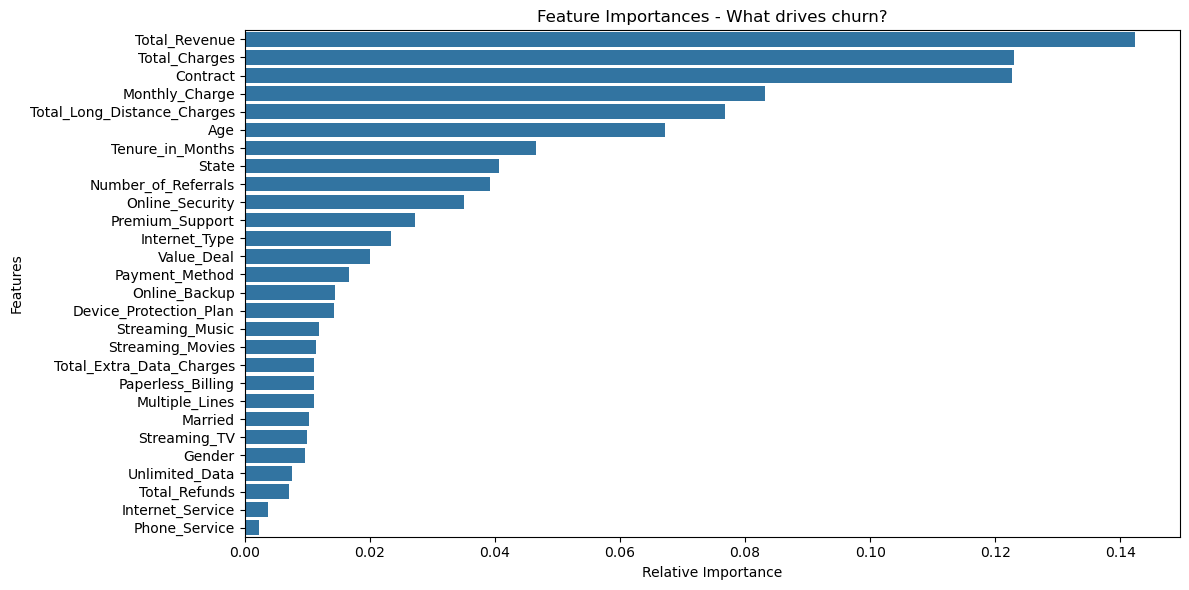


Top 5 churn drivers:
1. Total_Revenue: 0.142
2. Total_Charges: 0.123
3. Contract: 0.123
4. Monthly_Charge: 0.083
5. Total_Long_Distance_Charges: 0.077


In [9]:
# -----------------------------------------------
# STEP 7: FEATURE IMPORTANCE
# -----------------------------------------------

# Get feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances - What drives churn?')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig(r'C:\Users\iampr\OneDrive\Desktop\feature_importance.png')
plt.show()

print("\nTop 5 churn drivers:")
for i in range(5):
    print(f"{i+1}. {X.columns[indices[i]]}: {importances[indices[i]]:.3f}")

In [10]:
# -----------------------------------------------
# STEP 8: PREDICT NEW JOINERS
# -----------------------------------------------

# Prepare joiner data
joiner_original = joiner_data.copy()
customer_ids = joiner_data['Customer_ID']

# Drop columns not needed
joiner_data = joiner_data.drop(
    ['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], 
    axis=1
)

# Encode joiner data using same encoders
for column in columns_to_encode:
    joiner_data[column] = label_encoders[column].transform(joiner_data[column])

# Make predictions
predictions = rf_model.predict(joiner_data)

# Add predictions to original data
joiner_original['Churn_Predicted'] = predictions

# Filter only predicted churners
predicted_churners = joiner_original[joiner_original['Churn_Predicted'] == 1]

print("Total new joiners scored:", len(joiner_original))
print("Predicted to churn:", len(predicted_churners))
print("Churn risk percentage:", 
      round(len(predicted_churners)/len(joiner_original)*100, 1), "%")

# Save results
predicted_churners.to_csv(
    r'C:\Users\iampr\OneDrive\Desktop\Predicted_Churners.csv', 
    index=False
)

print("\n✅ Predictions saved to Desktop!")

Total new joiners scored: 411
Predicted to churn: 380
Churn risk percentage: 92.5 %

✅ Predictions saved to Desktop!


In [11]:
# -----------------------------------------------
# STEP 9: SAVE THE MODEL
# -----------------------------------------------

# Save the trained model
joblib.dump(rf_model, r'C:\Users\iampr\OneDrive\Desktop\churn_model.pkl')

# Save the label encoders
joblib.dump(label_encoders, r'C:\Users\iampr\OneDrive\Desktop\label_encoders.pkl')

print("✅ Model saved as churn_model.pkl")
print("✅ Label encoders saved as label_encoders.pkl")
print("\n🎉 Churn Prediction Pipeline Complete!")
print("Summary:")
print("  - Model Accuracy: 84%")
print("  - Churners caught: 227 out of 361")
print("  - New joiners at risk:", 380, "out of 411")

✅ Model saved as churn_model.pkl
✅ Label encoders saved as label_encoders.pkl

🎉 Churn Prediction Pipeline Complete!
Summary:
  - Model Accuracy: 84%
  - Churners caught: 227 out of 361
  - New joiners at risk: 380 out of 411
